# Comparing inference methods: NUTS, SVI, and Pathfinder with `numpyro_forecast`

One advantage of writing a forecasting model once is that you can fit it with different inference engines without touching the model code. In this notebook we take the weekly BART ridership model from the [univariate forecasting example](forecasting_univariate.html) (a random-walk local level, Fourier seasonality, and a Student-T likelihood) and fit it three ways: with **NUTS** (Markov chain Monte Carlo), with **SVI** (stochastic variational inference, using a custom [optax](https://optax.readthedocs.io/en/latest/) optimizer), and with **Pathfinder** (quasi-Newton variational inference from [BlackJAX](https://blackjax-devs.github.io/blackjax/)).

Every engine returns a small fit object that flows through the same functional pipeline: `draw_posterior` for latent draws, `forecast` for the test horizon, and `to_datatree` plus `add_forecast_groups` for an ArviZ `DataTree` that powers both the plots and the evaluation. We compare the three engines on the continuous ranked probability score (CRPS) over the training and test windows, and on wall-clock time.

## Prepare notebook

In [1]:
from time import perf_counter

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import optax
import pandas as pd
import xarray as xr
from jax import random
from numpyro.infer.reparam import LocScaleReparam

from numpyro_forecast import add_forecast_groups, eval_crps, to_datatree
from numpyro_forecast.contrib.blackjax import fit_pathfinder
from numpyro_forecast.datasets import load_bart_weekly
from numpyro_forecast.features import fourier_features
from numpyro_forecast.functional import (
    Horizon,
    draw_posterior,
    fit_mcmc,
    fit_svi,
    forecast,
    forecasting_model,
    predict,
    time_series,
)
from numpyro_forecast.typing import Array

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)

%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

## Read data

We work with total weekly BART ridership on the log scale, exactly as in the univariate example. Throughout the package, time lives at axis `-2` and the observation dimension at axis `-1`, so the series has shape `(weeks, 1)`.

In [2]:
data = load_bart_weekly()  # (weeks, 1), log scale
duration = data.shape[0]
print("data shape:", data.shape)

data shape: (469, 1)


## Train-test split

We hold out the last `52` weeks (one full year) as the test set and train on the preceding `417` weeks, so the test window covers a complete seasonal cycle.

train: (417, 1) test: (52, 1)


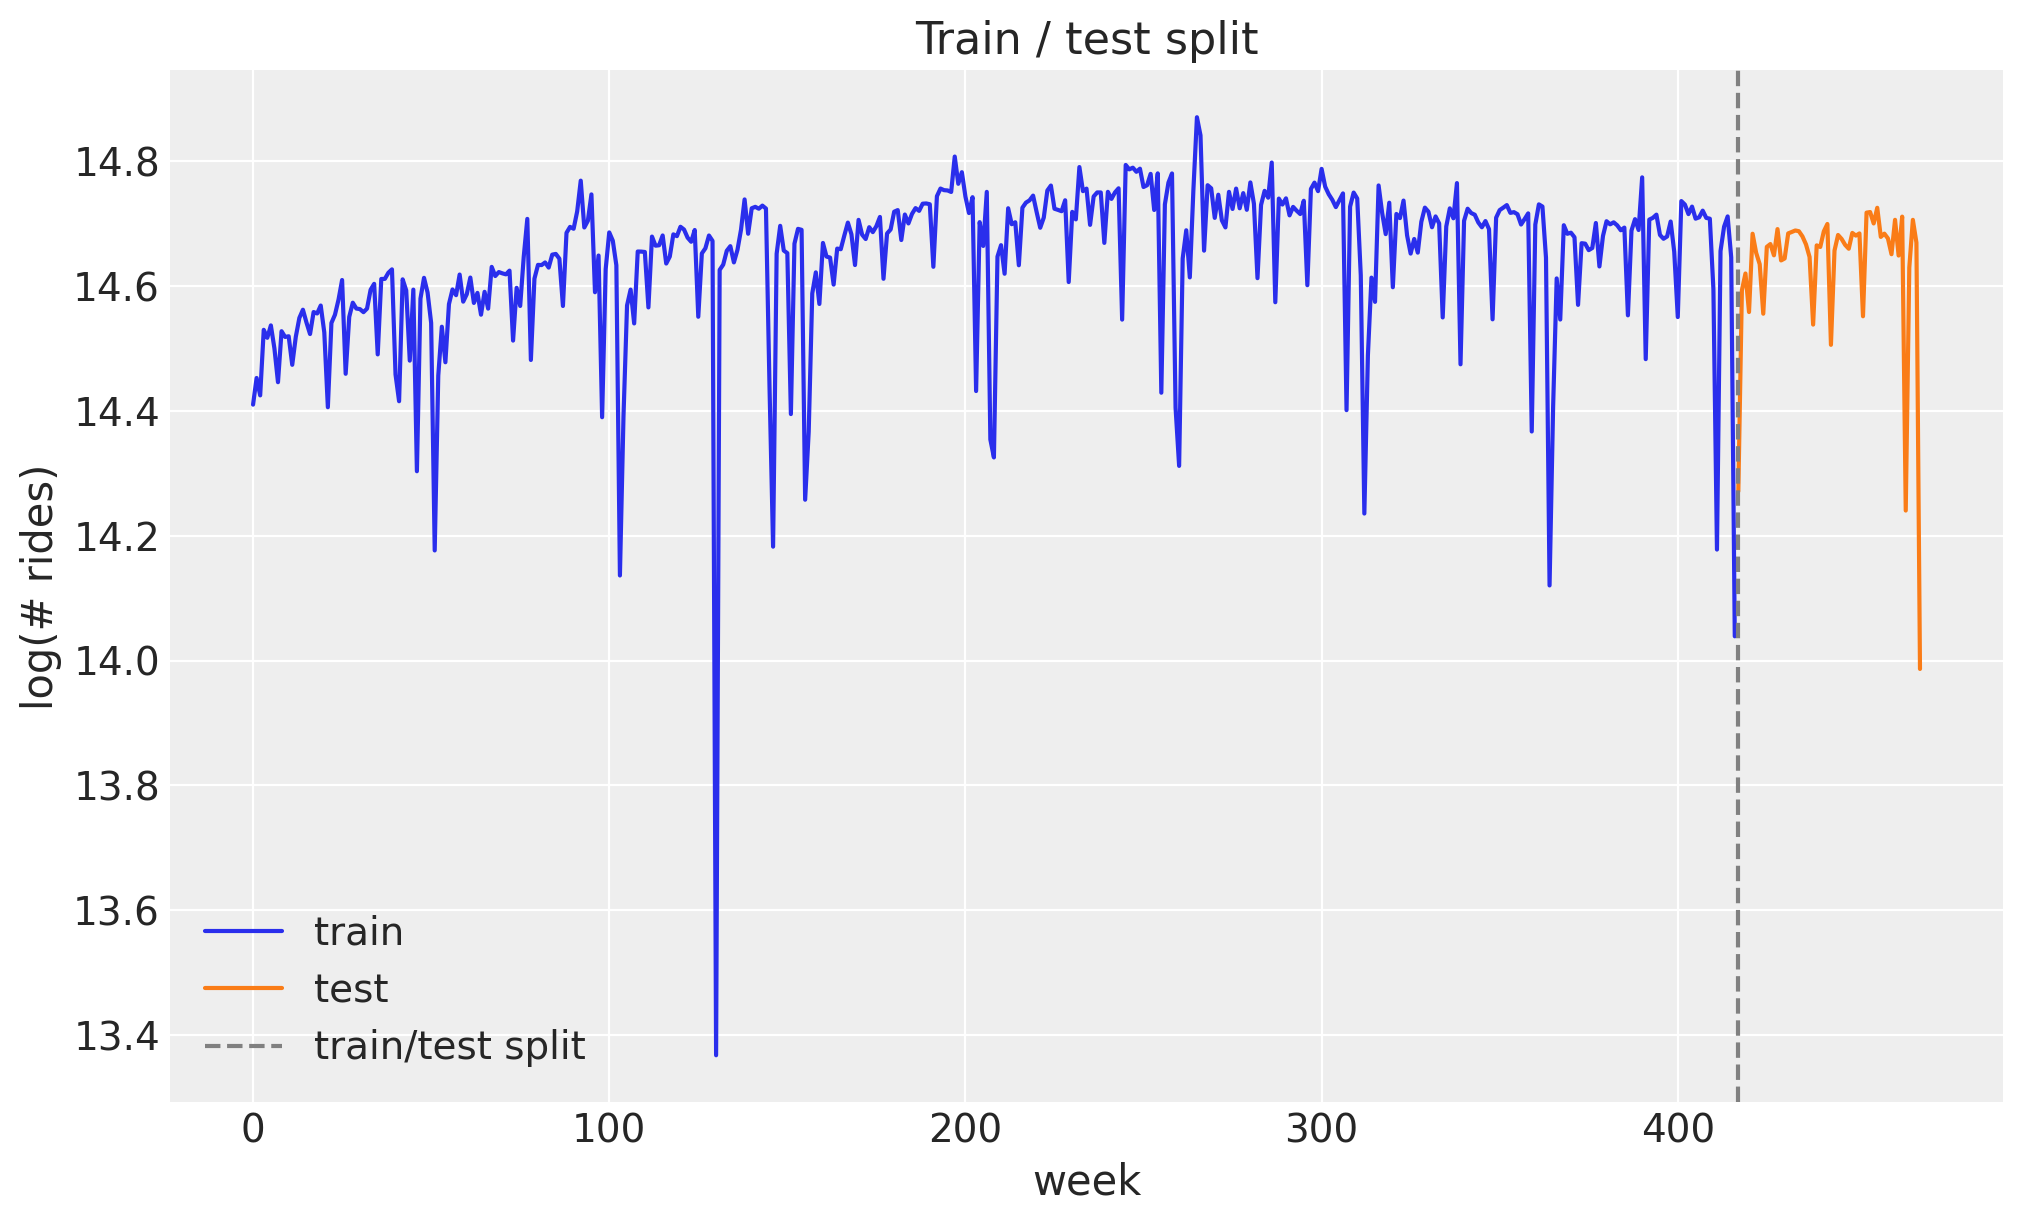

In [3]:
T0 = 0
T2 = duration  # 469
T1 = T2 - 52  # 417: train / test split

y_train = data[T0:T1]
y_test = data[T1:T2]

time = np.arange(T2)
time_train = time[T0:T1]
time_test = time[T1:T2]
print("train:", y_train.shape, "test:", y_test.shape)

fig, ax = plt.subplots()
ax.plot(time_train, np.asarray(y_train[:, 0]), color="C0", label="train")
ax.plot(time_test, np.asarray(y_test[:, 0]), color="C1", label="test")
ax.axvline(T1, color="gray", ls="--", label="train/test split")
ax.legend()
ax.set(title="Train / test split", xlabel="week", ylabel="log(# rides)");

## Seasonal features

The annual cycle enters through a Fourier design matrix built with `fourier_features`: `26` harmonics (so `52` sine and cosine columns) at a period of `365.25 / 7` weeks, paired with a $\text{Normal}(0, 0.1)$ prior on the weights.

In [4]:
num_terms = 26
covariates = fourier_features(duration, period=365.25 / 7, num_terms=num_terms)
covariates_train = covariates[T0:T1]
print("covariates shape:", covariates.shape)

covariates shape: (469, 52)


## Model specification

The model is a *local level with seasonality*: the mean combines a global `bias`, a random-walk level $\ell_t$ that drifts by small Gaussian increments $\delta_t$, and a Fourier regression for the annual cycle, with a heavy-tailed Student-T likelihood to absorb outlier weeks.

\begin{align*}
\mu_t  & = \text{bias} + \ell_t + w^\top x_t, \\
\ell_t & = \ell_{t-1} + \delta_t, \\
\delta_t & \sim \text{Normal}(0, \sigma_\text{drift}), \\
y_t & \sim \text{StudentT}(\nu, \mu_t, \sigma).
\end{align*}

We write the generative story once, as a plain function `(Horizon, covariates) -> None`, and wrap it with `forecasting_model` (the functional twin of subclassing `ForecastingModel`; the univariate example shows both styles and checks that they are interchangeable). The level is the cumulative sum of the `drift` increments sampled with `time_series`, and the single call to `predict` registers the zero-centered Student-T noise around the predicted mean while wiring up the train-versus-forecast machinery. The `LocScaleReparam` on the drift lets the model interpolate between centered and non-centered parameterizations, which helps the optimization geometry for the variational fits and the sampling geometry for NUTS alike.

In [5]:
@forecasting_model
def univariate_model(h: Horizon, covariates: Array) -> None:
    """Local level + Fourier regression with Student-T observations."""
    num_features = covariates.shape[-1]

    bias = numpyro.sample("bias", dist.Normal(0.0, 10.0))
    weight = numpyro.sample("weight", dist.Normal(0.0, 0.1).expand([num_features]).to_event(1))
    drift_scale = numpyro.sample("drift_scale", dist.LogNormal(-20.0, 5.0))
    nu = numpyro.sample("nu", dist.Gamma(10.0, 2.0))
    sigma = numpyro.sample("sigma", dist.LogNormal(-5.0, 5.0))
    centered = numpyro.sample("centered", dist.Uniform(0.0, 1.0))

    drift = time_series(
        h,
        "drift",
        lambda: dist.Normal(0.0, drift_scale),
        reparam=LocScaleReparam(centered=centered),
    )
    level = jnp.cumsum(drift, axis=-2)
    regression = (weight * covariates).sum(axis=-1, keepdims=True)
    prediction = level + bias + regression

    predict(h, dist.StudentT(df=nu, loc=0.0, scale=sigma), prediction)

Let's visualize the model:

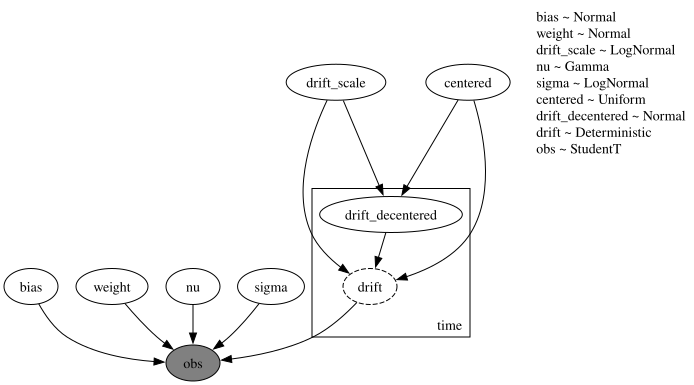

In [6]:
numpyro.render_model(
    univariate_model,
    model_args=(covariates_train, y_train),
    render_distributions=True,
)

## Inference

We now fit the same model three times, once per inference engine. Each `fit_*` function consumes the training data and covariates and returns a small frozen fit object (`MCMCFit`, `SVIFit`, `PathfinderFit`) that plugs into the same downstream pipeline, so switching engines is a one-line change. In brief:

- **NUTS** (the No-U-Turn Sampler) is gradient-based Markov chain Monte Carlo. It draws asymptotically exact samples from the posterior, which makes it our reference here, at the highest computational cost of the three.
- **SVI** (stochastic variational inference) turns inference into optimization: it fits the parameters of an approximating guide distribution (here `AutoNormal`, a diagonal Gaussian) by maximizing the evidence lower bound (ELBO). It is much faster than MCMC, and its accuracy is bounded by how well the guide family can match the true posterior.
- **Pathfinder** is quasi-Newton variational inference. It runs L-BFGS toward the posterior mode and recycles the optimization path into a sequence of normal approximations, returning the one with the best ELBO. It is the cheapest of the three and is often used for fast approximate posteriors or to initialize MCMC.

The object-oriented wrappers `HMCForecaster`, `Forecaster`, and `PathfinderForecaster` bundle these same fits with prediction methods, but here we stay with the functional API because the fit objects are exactly what the ArviZ export below consumes.

### NUTS

We run `4` chains in parallel with `2_000` warmup steps and `1_000` posterior draws each. The posterior includes one drift increment per training week (417 of them), so this is the most expensive fit in the notebook.

In [7]:
rng_key, rng_subkey = random.split(rng_key)

start = perf_counter()
nuts_fit = fit_mcmc(
    rng_subkey,
    univariate_model,
    y_train,
    covariates_train,
    num_warmup=2_000,
    num_samples=1_000,
    num_chains=4,
    chain_method="parallel",
)
jax.block_until_ready(nuts_fit.samples)
nuts_seconds = perf_counter() - start
print(f"NUTS: 4 chains x 1_000 draws in {nuts_seconds:.1f}s")

NUTS: 4 chains x 1_000 draws in 34.3s


### SVI

`fit_svi` resolves its `optim` argument through `resolve_optimizer`, which accepts a plain learning rate, a NumPyro optimizer, or any optax `GradientTransformation`. We use that last option to build a custom optimizer from two pieces:

- A **one-cycle** learning-rate schedule (`optax.linear_onecycle_schedule`): a linear warmup to a peak followed by a long annealing phase. The warmup lets the optimizer pass through a much higher mid-run learning rate than a fixed setting could tolerate, and the final annealing polishes the optimum.
- **Reduce-on-plateau** (`optax.contrib.reduce_on_plateau`): an adaptive safeguard that scales the updates down by `factor=0.8` whenever the ELBO, averaged over `accumulation_size=100` steps, stops improving for `patience=20` consecutive windows. NumPyro forwards the per-step ELBO value to the optimizer chain, which is exactly the signal this transformation monitors.

The univariate example needs `50_000` steps at a fixed `Adam(0.005)`; cycling up to a peak of `0.01` reaches a slightly better ELBO in `20_000` steps, less than half the budget.

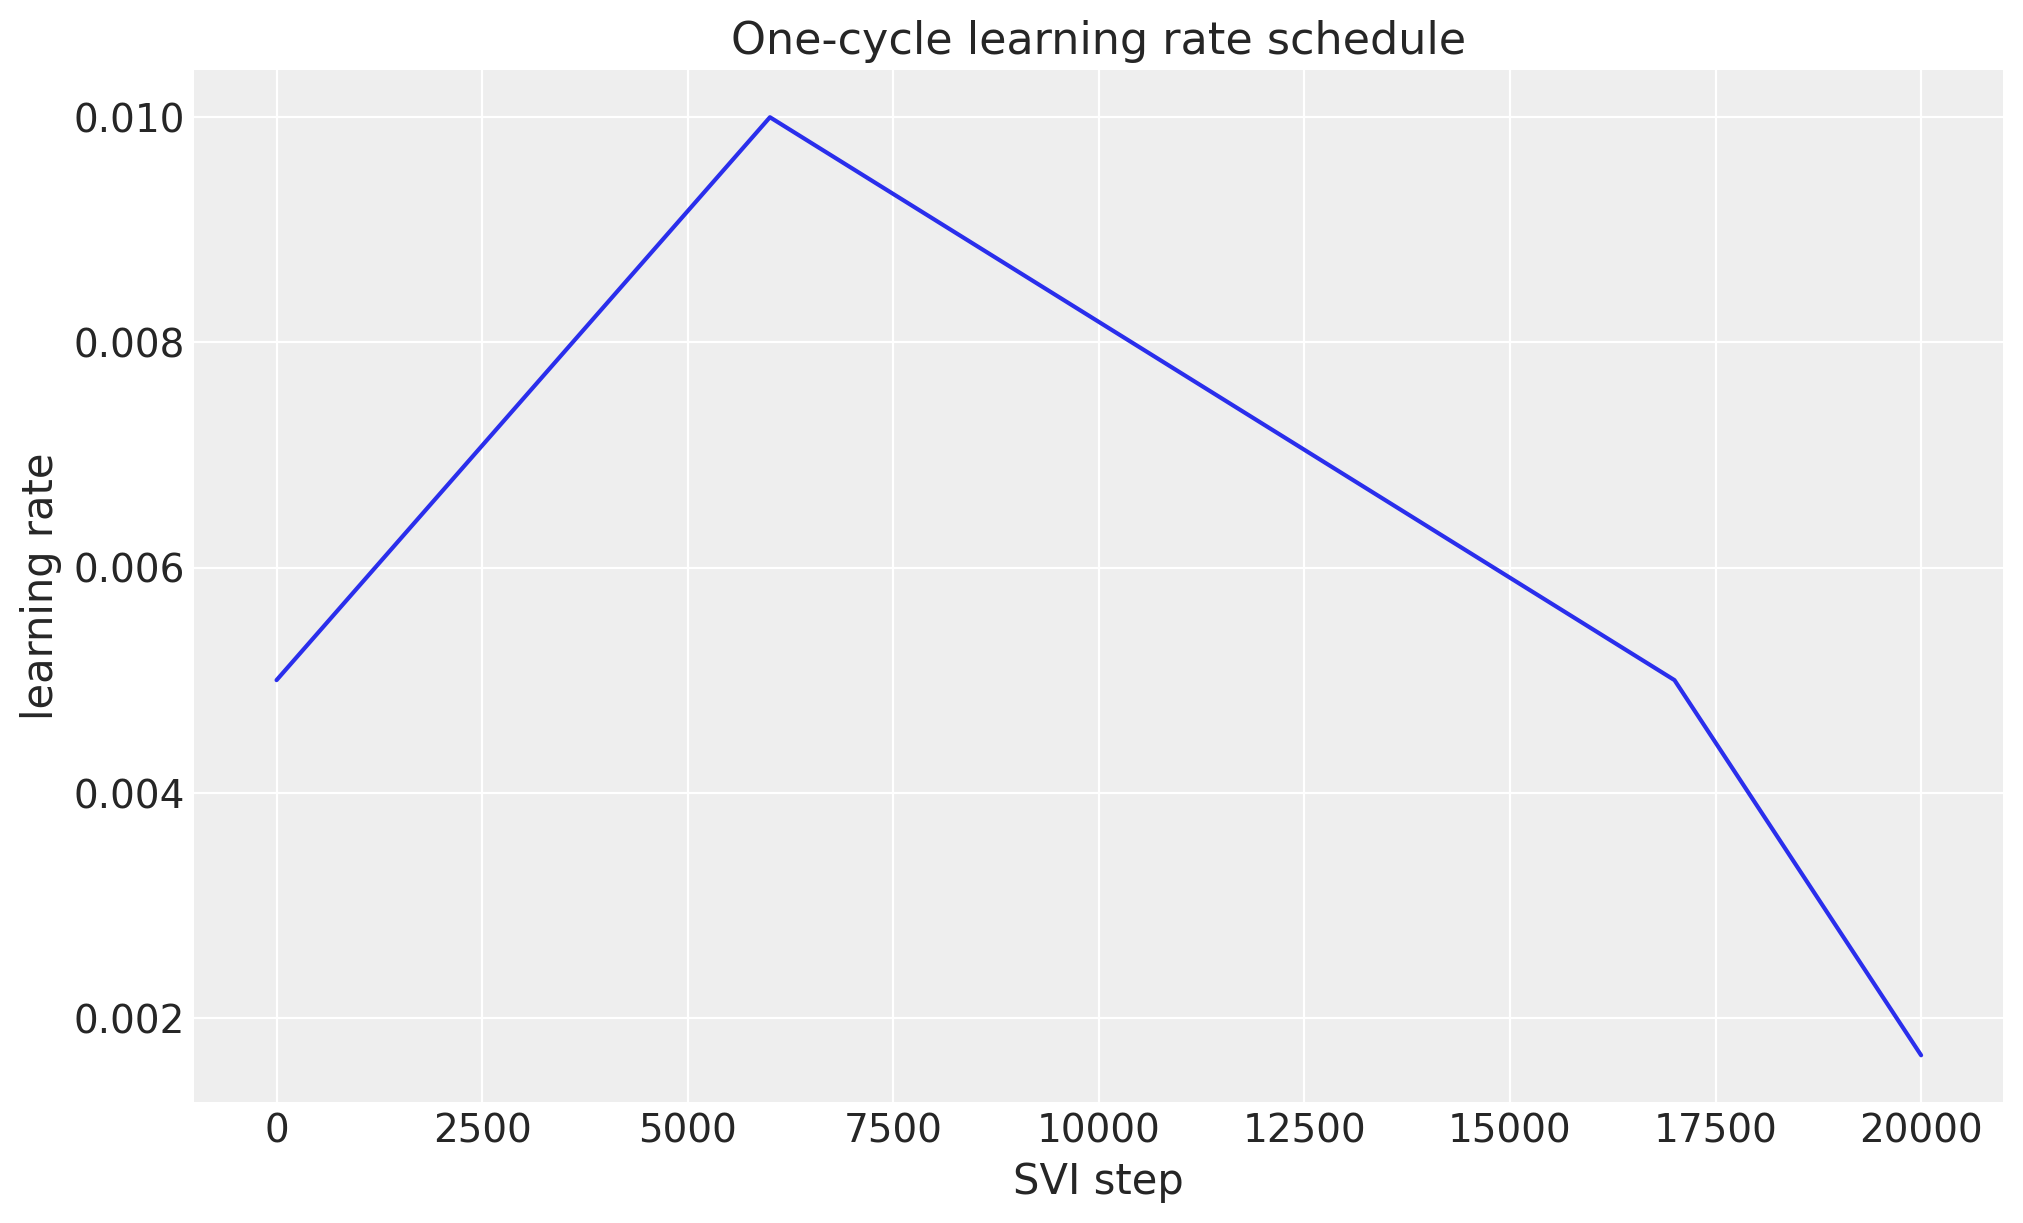

In [8]:
num_steps = 20_000

scheduler = optax.linear_onecycle_schedule(
    transition_steps=num_steps,
    peak_value=0.01,
    pct_start=0.3,
    pct_final=0.85,
    div_factor=2,
    final_div_factor=3,
)

optimizer = optax.chain(
    optax.adam(learning_rate=scheduler),
    optax.contrib.reduce_on_plateau(
        factor=0.8,
        patience=20,
        accumulation_size=100,
    ),
)

fig, ax = plt.subplots()
ax.plot(np.asarray(jax.vmap(scheduler)(jnp.arange(num_steps))), color="C0")
ax.set(title="One-cycle learning rate schedule", xlabel="SVI step", ylabel="learning rate");

SVI: 20_000 steps in 4.2s


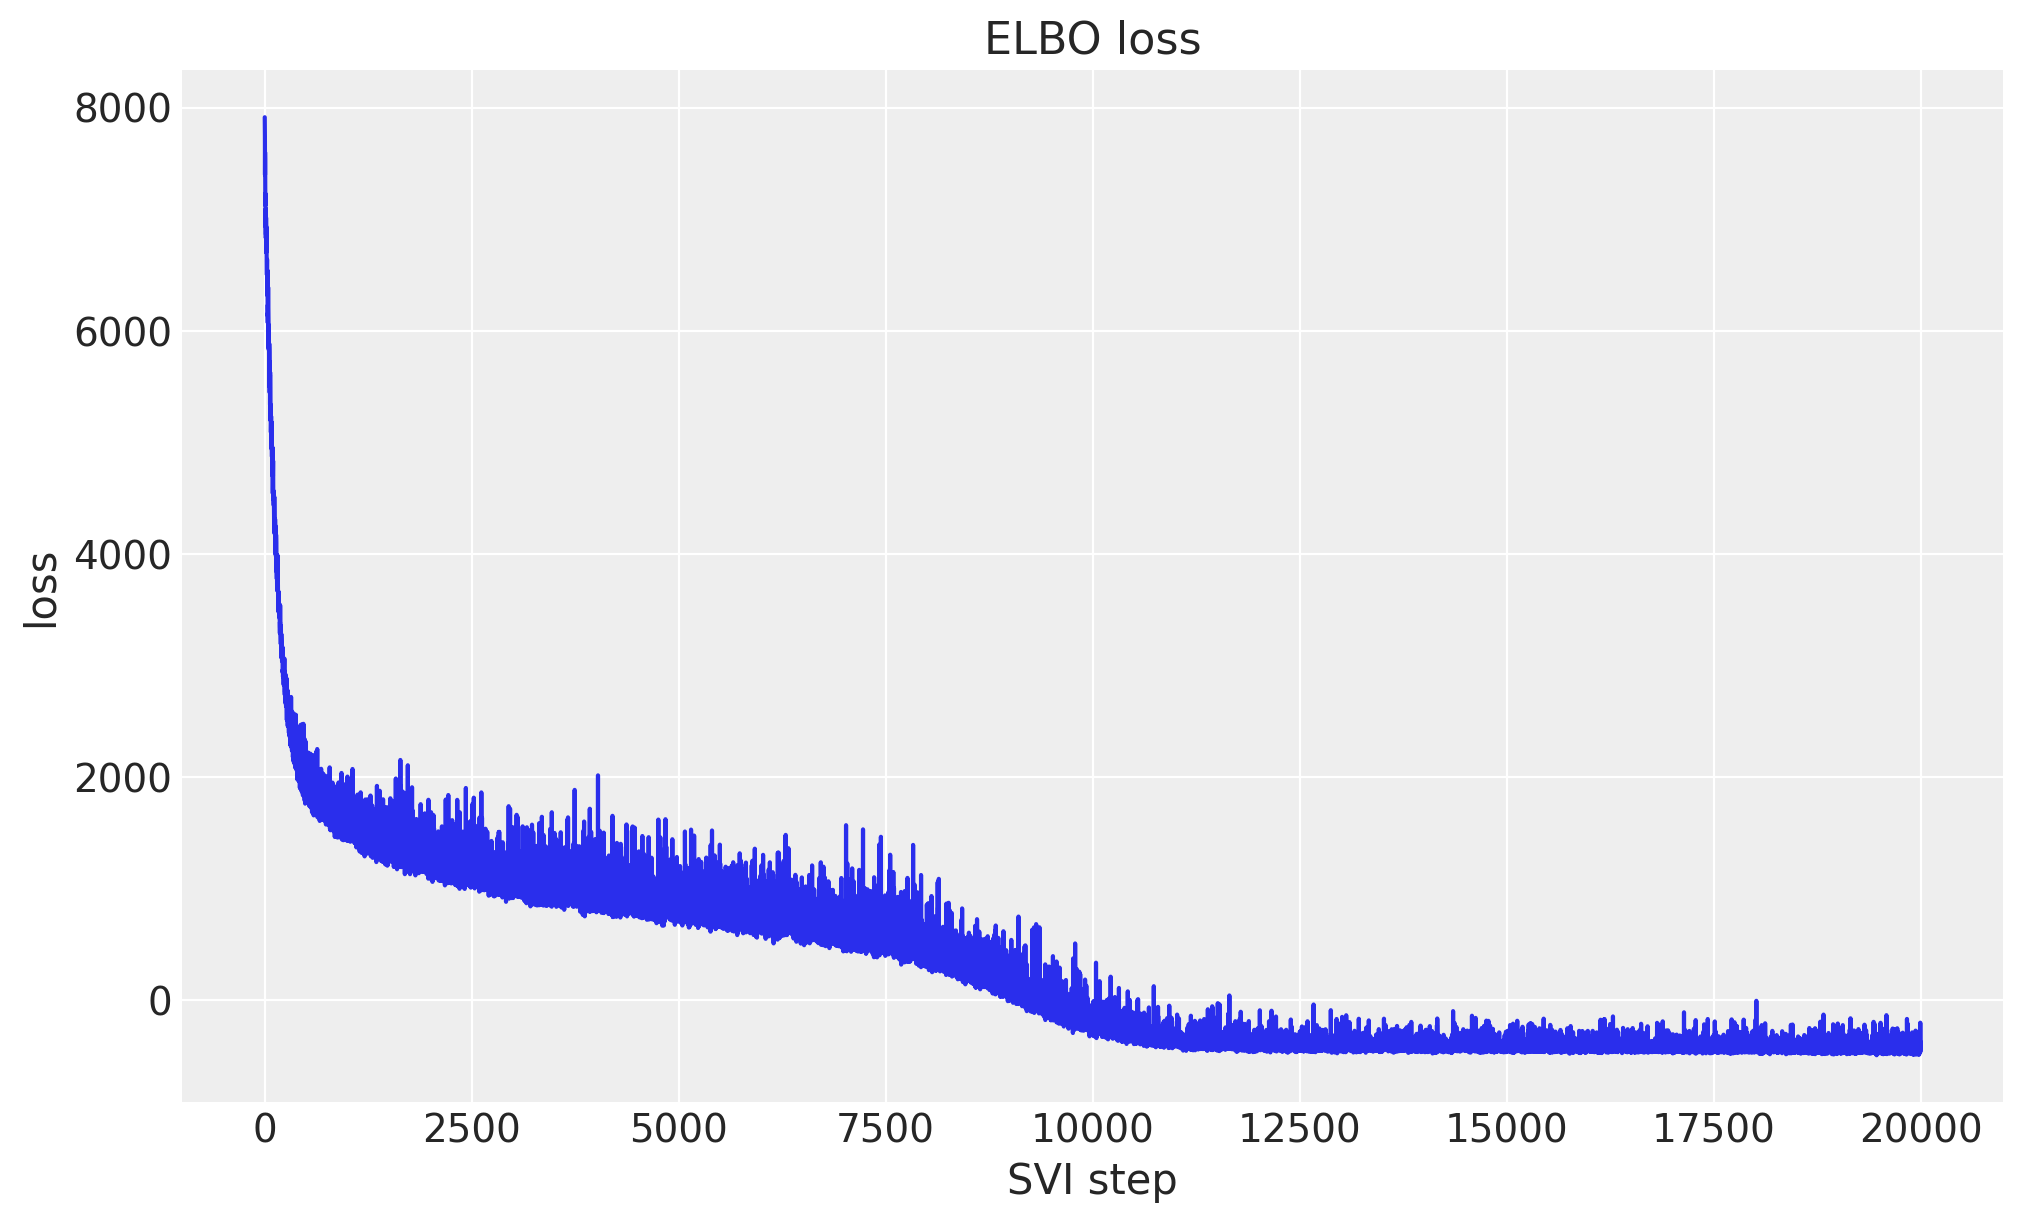

In [9]:
rng_key, rng_subkey = random.split(rng_key)

start = perf_counter()
svi_fit = fit_svi(
    rng_subkey,
    univariate_model,
    y_train,
    covariates_train,
    optim=optimizer,
    num_steps=num_steps,
)
jax.block_until_ready(svi_fit.losses)
svi_seconds = perf_counter() - start
print(f"SVI: {num_steps:_} steps in {svi_seconds:.1f}s")

fig, ax = plt.subplots()
ax.plot(svi_fit.losses)
ax.set(title="ELBO loss", xlabel="SVI step", ylabel="loss");

### Pathfinder

`fit_pathfinder` lives in `numpyro_forecast.contrib.blackjax` and needs the optional BlackJAX backend (install it with `pip install "numpyro_forecast[blackjax]"`). A single L-BFGS run traces a path toward the posterior mode, each point on the path induces a normal approximation, and the fit keeps the one with the best ELBO estimate.

Two settings matter here. The first is `maxiter`, the L-BFGS iteration budget: the default (`30`) suits posteriors with a handful of parameters, but ours has one drift increment per training week and needs a few hundred iterations to approach the high-density region. The second is the number of paths: a single Pathfinder run is noisy, because the quality of the approximation depends on where its optimization path happens to wander, so standard practice (the *multi-path* variant in the paper) is to run a few independent paths and keep the one with the best ELBO. We run `4` paths of `500` iterations each; the paths are fully independent, so in a production setting they can run in parallel.

In [10]:
rng_key, rng_subkey = random.split(rng_key)
num_paths = 4

start = perf_counter()
path_fits = [
    fit_pathfinder(path_key, univariate_model, y_train, covariates_train, maxiter=500)
    for path_key in random.split(rng_subkey, num_paths)
]
pathfinder_fit = max(path_fits, key=lambda fit: fit.elbo)
pathfinder_seconds = perf_counter() - start

print("per-path ELBO:", [round(fit.elbo, 1) for fit in path_fits])
print(f"Pathfinder: best ELBO {pathfinder_fit.elbo:.2f} in {pathfinder_seconds:.1f}s")

per-path ELBO: [-1620.3, -2197.9, -1690.8, -1234.4]
Pathfinder: best ELBO -1234.40 in 14.3s


## Exporting fits to ArviZ

`to_datatree` converts any of the three fit objects into an ArviZ-schema `xarray.DataTree` with `posterior`, `posterior_predictive`, `observed_data`, and `constant_data` groups. An MCMC fit keeps its real chain structure, so convergence diagnostics work out of the box, while the variational fits get a single pseudo chain and a `variational: True` attribute. `add_forecast_groups` then appends the out-of-sample forecast draws as `predictions` and `predictions_constant_data` groups, continuing the in-sample time coordinate.

The pipeline is identical for the three engines, so we wrap it in a helper. The only cosmetic post-processing is for plotting: this series is univariate, so we drop the singleton observation dimension and expose the week index as a variable that `az.plot_lm` can use as the x axis.

In [11]:
def build_tree(rng_key: Array, fit: object, num_samples: int = 2_000) -> xr.DataTree:
    """Export a fit to an ArviZ ``DataTree`` with in-sample and forecast groups."""
    key_tree, key_post, key_fc = random.split(rng_key, 3)
    tree = to_datatree(
        key_tree,
        fit,
        univariate_model,
        y_train,
        covariates_train,
        num_predictive_samples=num_samples,
        posterior_dims={"drift": ["time"]},
    )
    posterior = draw_posterior(key_post, fit, num_samples)
    forecast_samples = forecast(key_fc, univariate_model, posterior, y_train, covariates)
    tree = add_forecast_groups(tree, forecast_samples, covariates[T1:])
    for group in ("posterior_predictive", "observed_data", "predictions"):
        tree[group] = tree[group].dataset.isel(obs_dim=0)
    tree["constant_data"] = tree["constant_data"].dataset.assign(
        week=("time", time_train.astype(float))
    )
    tree["predictions_constant_data"] = tree["predictions_constant_data"].dataset.assign(
        week=("time", time_test.astype(float))
    )
    return tree


rng_key, key_nuts, key_svi, key_pf = random.split(rng_key, 4)
nuts_tree = build_tree(key_nuts, nuts_fit)
svi_tree = build_tree(key_svi, svi_fit)
pathfinder_tree = build_tree(key_pf, pathfinder_fit)

nuts_tree

<xarray.DataTree>
Group: /
│   Attributes:
│       inference_library:  numpyro
│       creation_library:   numpyro_forecast
│       sample_dims:        ['chain', 'draw']
├── Group: /posterior
│       Dimensions:                 (chain: 4, draw: 1000, time: 417, drift_dim_0: 1,
│                                    drift_decentered_dim_0: 417,
│                                    drift_decentered_dim_1: 1, weight_dim_0: 52)
│       Coordinates:
│         * chain                   (chain) int64 32B 0 1 2 3
│         * draw                    (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
│         * time                    (time) int64 3kB 0 1 2 3 4 5 ... 412 413 414 415 416
│         * drift_dim_0             (drift_dim_0) int64 8B 0
│         * drift_decentered_dim_0  (drift_decentered_dim_0) int64 3kB 0 1 2 ... 415 416
│         * drift_decentered_dim_1  (drift_decentered_dim_1) int64 8B 0
│         * weight_dim_0            (weight_dim_0) int64 416B 0 1 2 3 4 ... 48 49 50 51
│       Data variables:
│           bias                    (chain, draw) float32 16kB 14.52 14.52 ... 14.52
│           centered                (chain, draw) float32 16kB 0.21 0.2209 ... 0.05874
│           drift                   (chain, draw, time, drift_dim_0) float32 7MB -0.0...
│           drift_decentered        (chain, draw, drift_decentered_dim_0, drift_decentered_dim_1) float32 7MB ...
│           drift_scale             (chain, draw) float32 16kB 0.004509 ... 0.004024
│           nu                      (chain, draw) float32 16kB 1.814 1.679 ... 1.412
│           sigma                   (chain, draw) float32 16kB 0.01851 ... 0.01748
│           weight                  (chain, draw, weight_dim_0) float32 832kB -0.0008...
│       Attributes:
│           created_at:                 2026-07-07T12:10:37.701245+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /posterior_predictive
│       Dimensions:  (chain: 4, draw: 1000, time: 417)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * time     (time) int64 3kB 0 1 2 3 4 5 6 7 ... 410 411 412 413 414 415 416
│           obs_dim  int64 8B 0
│       Data variables:
│           obs      (chain, draw, time) float32 7MB 14.41 14.47 14.43 ... 14.72 14.29
│       Attributes:
│           created_at:                 2026-07-07T12:10:38.259884+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:  (time: 417)
│       Coordinates:
│         * time     (time) int64 3kB 0 1 2 3 4 5 6 7 ... 410 411 412 413 414 415 416
│           obs_dim  int64 8B 0
│       Data variables:
│           obs      (time) float32 2kB 14.41 14.45 14.42 14.53 ... 14.71 14.65 14.04
│       Attributes:
│           created_at:                 2026-07-07T12:10:38.260156+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                []
├── Group: /constant_data
│       Dimensions:        (time: 417, covariate_dim: 52)
│       Coordinates:
│         * time           (time) int64 3kB 0 1 2 3 4 5 6 ... 411 412 413 414 415 416
│         * covariate_dim  (covariate_dim) int64 416B 0 1 2 3 4 5 ... 46 47 48 49 50 51
│       Data variables:
│           covariates     (time, covariate_dim) float32 87kB 0.0 0.0 ... -0.2376
│           week           (time) float64 3kB 0.0 1.0 2.0 3.0 ... 414.0 415.0 416.0
│       Attributes:
│           created_at:                 2026-07-07T12:10:38.260343+00:00
│           creation_library:           ArviZ
│           creation

### NUTS diagnostics

Because the NUTS tree keeps its `4` chains, the standard MCMC diagnostics apply directly to it: `az.summary` reports posterior summaries, effective sample sizes, and $\hat{R}$ for the scalar parameters. Values of $\hat{R}$ close to `1` indicate that the chains mixed well.

In [12]:
az.summary(nuts_tree, var_names=["bias", "drift_scale", "nu", "sigma", "centered"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
bias,14.5155,0.0107,14,15,478,886,1.01,0.00049,0.00036
drift_scale,0.00439,0.0007,0.0034,0.0056,357,726,1.01,3.7e-05,3.1e-05
nu,1.6,0.23,1.3,2,195,424,1.03,0.017,0.012
sigma,0.0175,0.0021,0.014,0.021,106,514,1.05,0.0002,0.00013
centered,0.3,0.21,0.058,0.66,5,9,2.10,0.098,0.048


The scalar parameters that shape the forecast (`bias`, `drift_scale`, `nu`, `sigma`) mix well. The exception is `centered`, and it is worth understanding why: this site only selects the drift's parameterization, so the joint density over the data is the same for every value of `centered` and its exact posterior equals its $\text{Uniform}(0, 1)$ prior. NUTS explores that flat direction slowly, which is exactly what the large $\hat{R}$ flags, but none of it leaks into the forecasts, which consume only the implied drift.

## CRPS on train and test

We score each engine with the **continuous ranked probability score** (CRPS), a proper scoring rule that compares a single observed value against the whole forecast distribution, rewarding forecasts that are both sharp and calibrated (lower is better). The in-sample score comes from the `posterior_predictive` group and the out-of-sample score from the `predictions` group, so the metrics are computed from the very same draws the plots below display.

In [13]:
def compute_crps(tree: xr.DataTree) -> dict[str, float]:
    """Score the in-sample and forecast draws in ``tree`` against the observed data."""
    pred_train = jnp.asarray(tree["posterior_predictive"]["obs"].values).reshape(-1, T1 - T0)
    pred_test = jnp.asarray(tree["predictions"]["obs"].values).reshape(-1, T2 - T1)
    return {
        "train": float(eval_crps(pred_train, y_train[:, 0])),
        "test": float(eval_crps(pred_test, y_test[:, 0])),
    }


crps_results = {
    "NUTS": compute_crps(nuts_tree),
    "SVI": compute_crps(svi_tree),
    "Pathfinder": compute_crps(pathfinder_tree),
}

comparison = pd.DataFrame(crps_results).T
comparison.columns = ["train CRPS", "test CRPS"]
comparison["walltime (s)"] = [nuts_seconds, svi_seconds, pathfinder_seconds]
comparison.round(4)

,train CRPS,test CRPS,walltime (s)
NUTS,0.0242,0.0302,34.3043
SVI,0.0270,0.0340,4.1540
Pathfinder,0.0300,0.0324,14.3144


## Forecast visualization

For each engine we overlay the in-sample posterior predictive (blue) and the forecast over the held-out year (orange), each with $50\%$ and $94\%$ HDI bands, on the observed series. The `DataTree` layout makes this a two-call `az.plot_lm` pattern: one call for the `posterior_predictive` group and one for the `predictions` group, sharing a single plot collection.

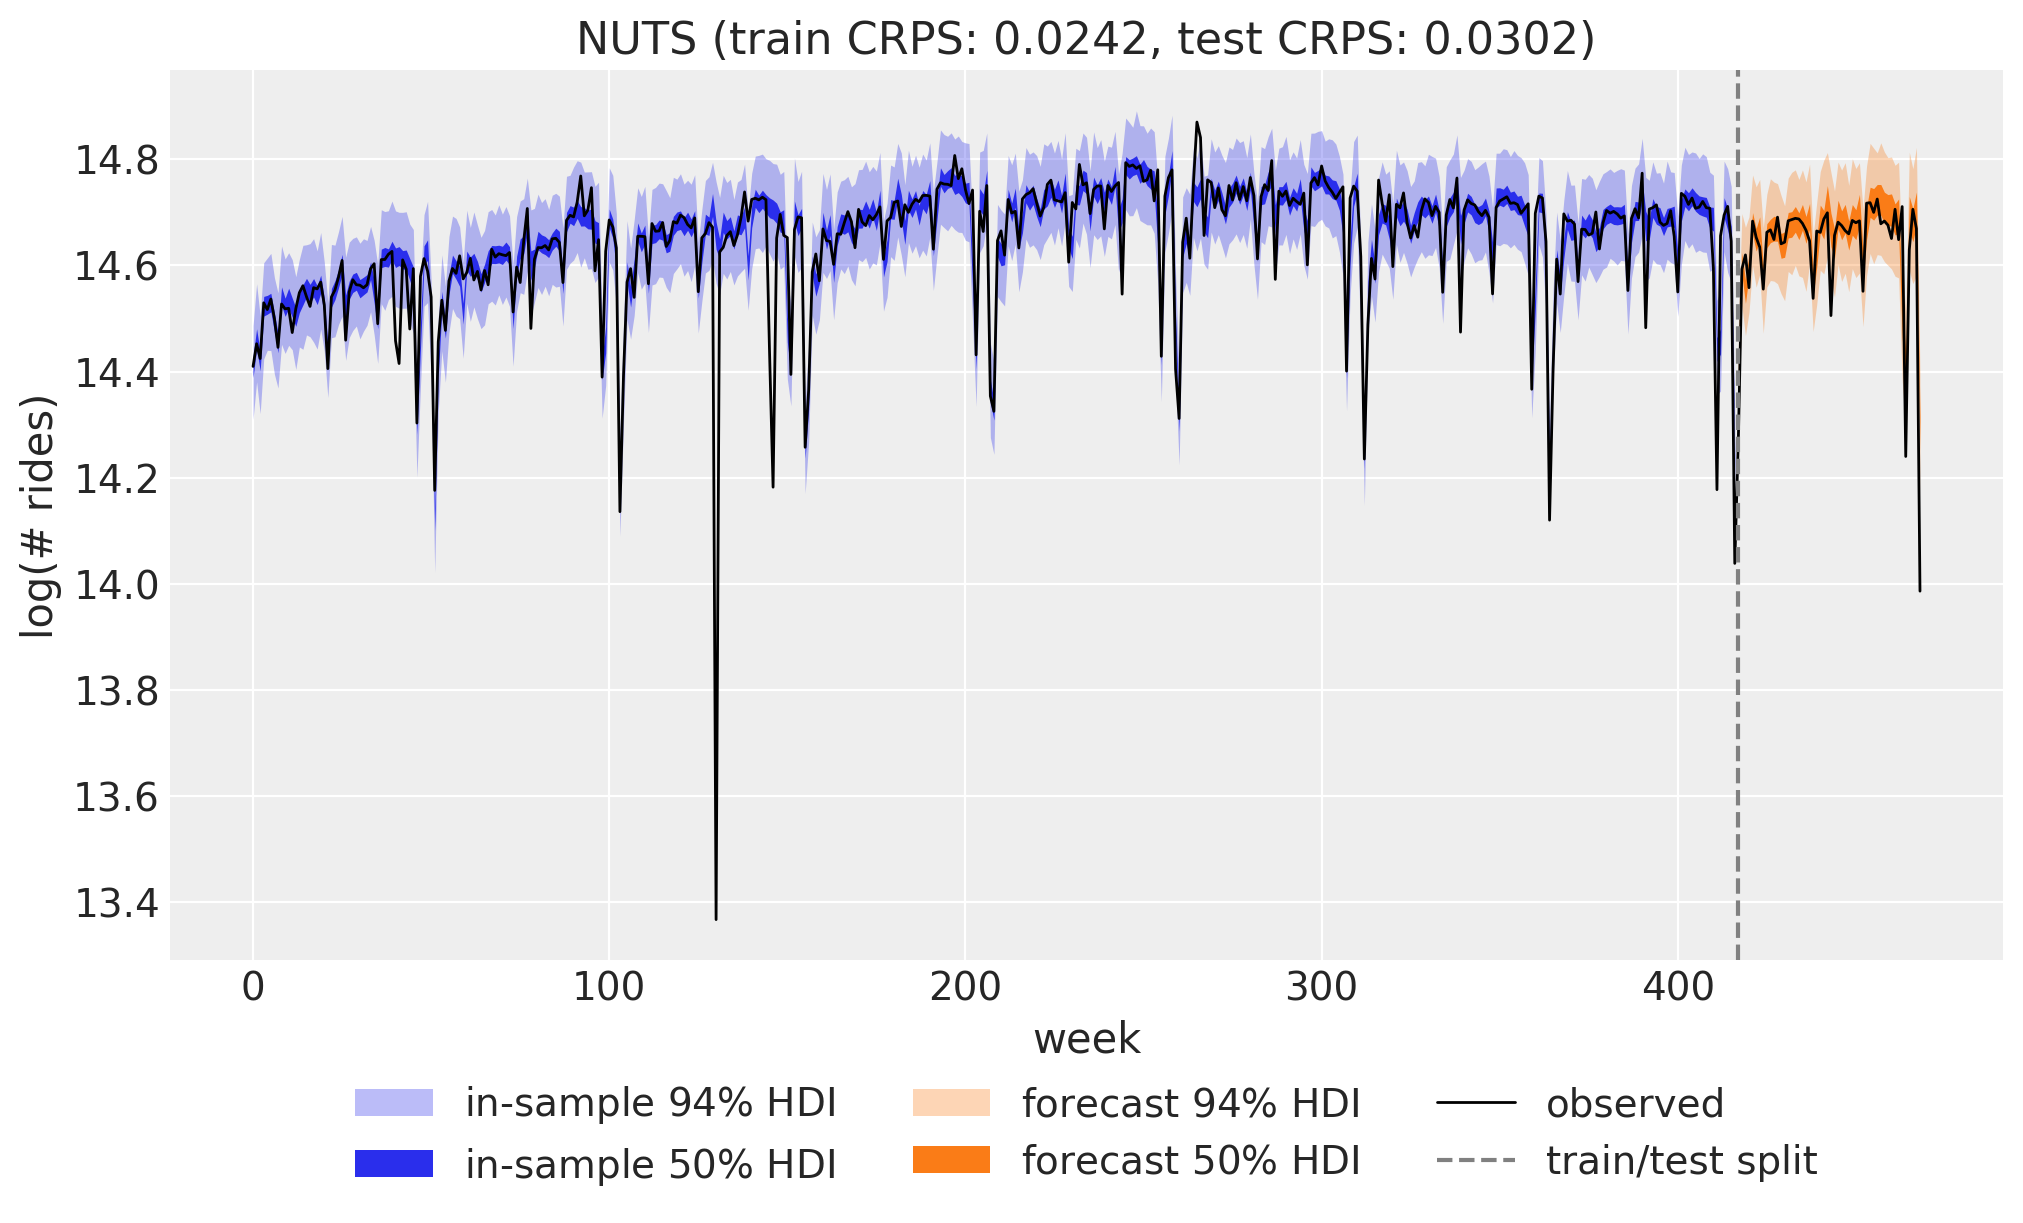

In [14]:
def crps_title(name: str) -> str:
    """Format a plot title with the method's train and test CRPS."""
    scores = crps_results[name]
    return f"{name} (train CRPS: {scores['train']:.4f}, test CRPS: {scores['test']:.4f})"


def plot_forecast(tree: xr.DataTree, title: str) -> None:
    """Overlay the in-sample and forecast HDI bands on the observed series."""
    pc = az.plot_lm(
        tree,
        y="obs",
        x="week",
        group="posterior_predictive",
        ci_kind="hdi",
        ci_prob=(0.5, 0.94),
        smooth=False,
        visuals={"ci_band": {"color": "C0"}, "observed_scatter": False, "pe_line": False},
        figure_kwargs={"figsize": (10, 6)},
    )
    train_bands = pc.viz["ci_band"]["week"]
    band_train_94 = train_bands.sel(prob=0.94).item()
    band_train_50 = train_bands.sel(prob=0.5).item()
    az.plot_lm(
        tree,
        y="obs",
        x="week",
        group="predictions",
        plot_collection=pc,
        ci_kind="hdi",
        ci_prob=(0.5, 0.94),
        smooth=False,
        visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
    )
    test_bands = pc.viz["ci_band"]["week"]
    band_test_94 = test_bands.sel(prob=0.94).item()
    band_test_50 = test_bands.sel(prob=0.5).item()
    ax = pc.viz["figure"].item().axes[0]
    band_train_94.set_label(r"in-sample $94\%$ HDI")
    band_train_50.set_label(r"in-sample $50\%$ HDI")
    band_test_94.set_label(r"forecast $94\%$ HDI")
    band_test_50.set_label(r"forecast $50\%$ HDI")
    (obs_line,) = ax.plot(time, np.asarray(data[:, 0]), color="black", lw=1, label="observed")
    split_line = ax.axvline(T1, color="gray", ls="--", label="train/test split")
    ax.legend(
        handles=[band_train_94, band_train_50, band_test_94, band_test_50, obs_line, split_line],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.1),
        ncol=3,
    )
    ax.set(title=title, ylabel="log(# rides)")


plot_forecast(nuts_tree, title=crps_title("NUTS"))

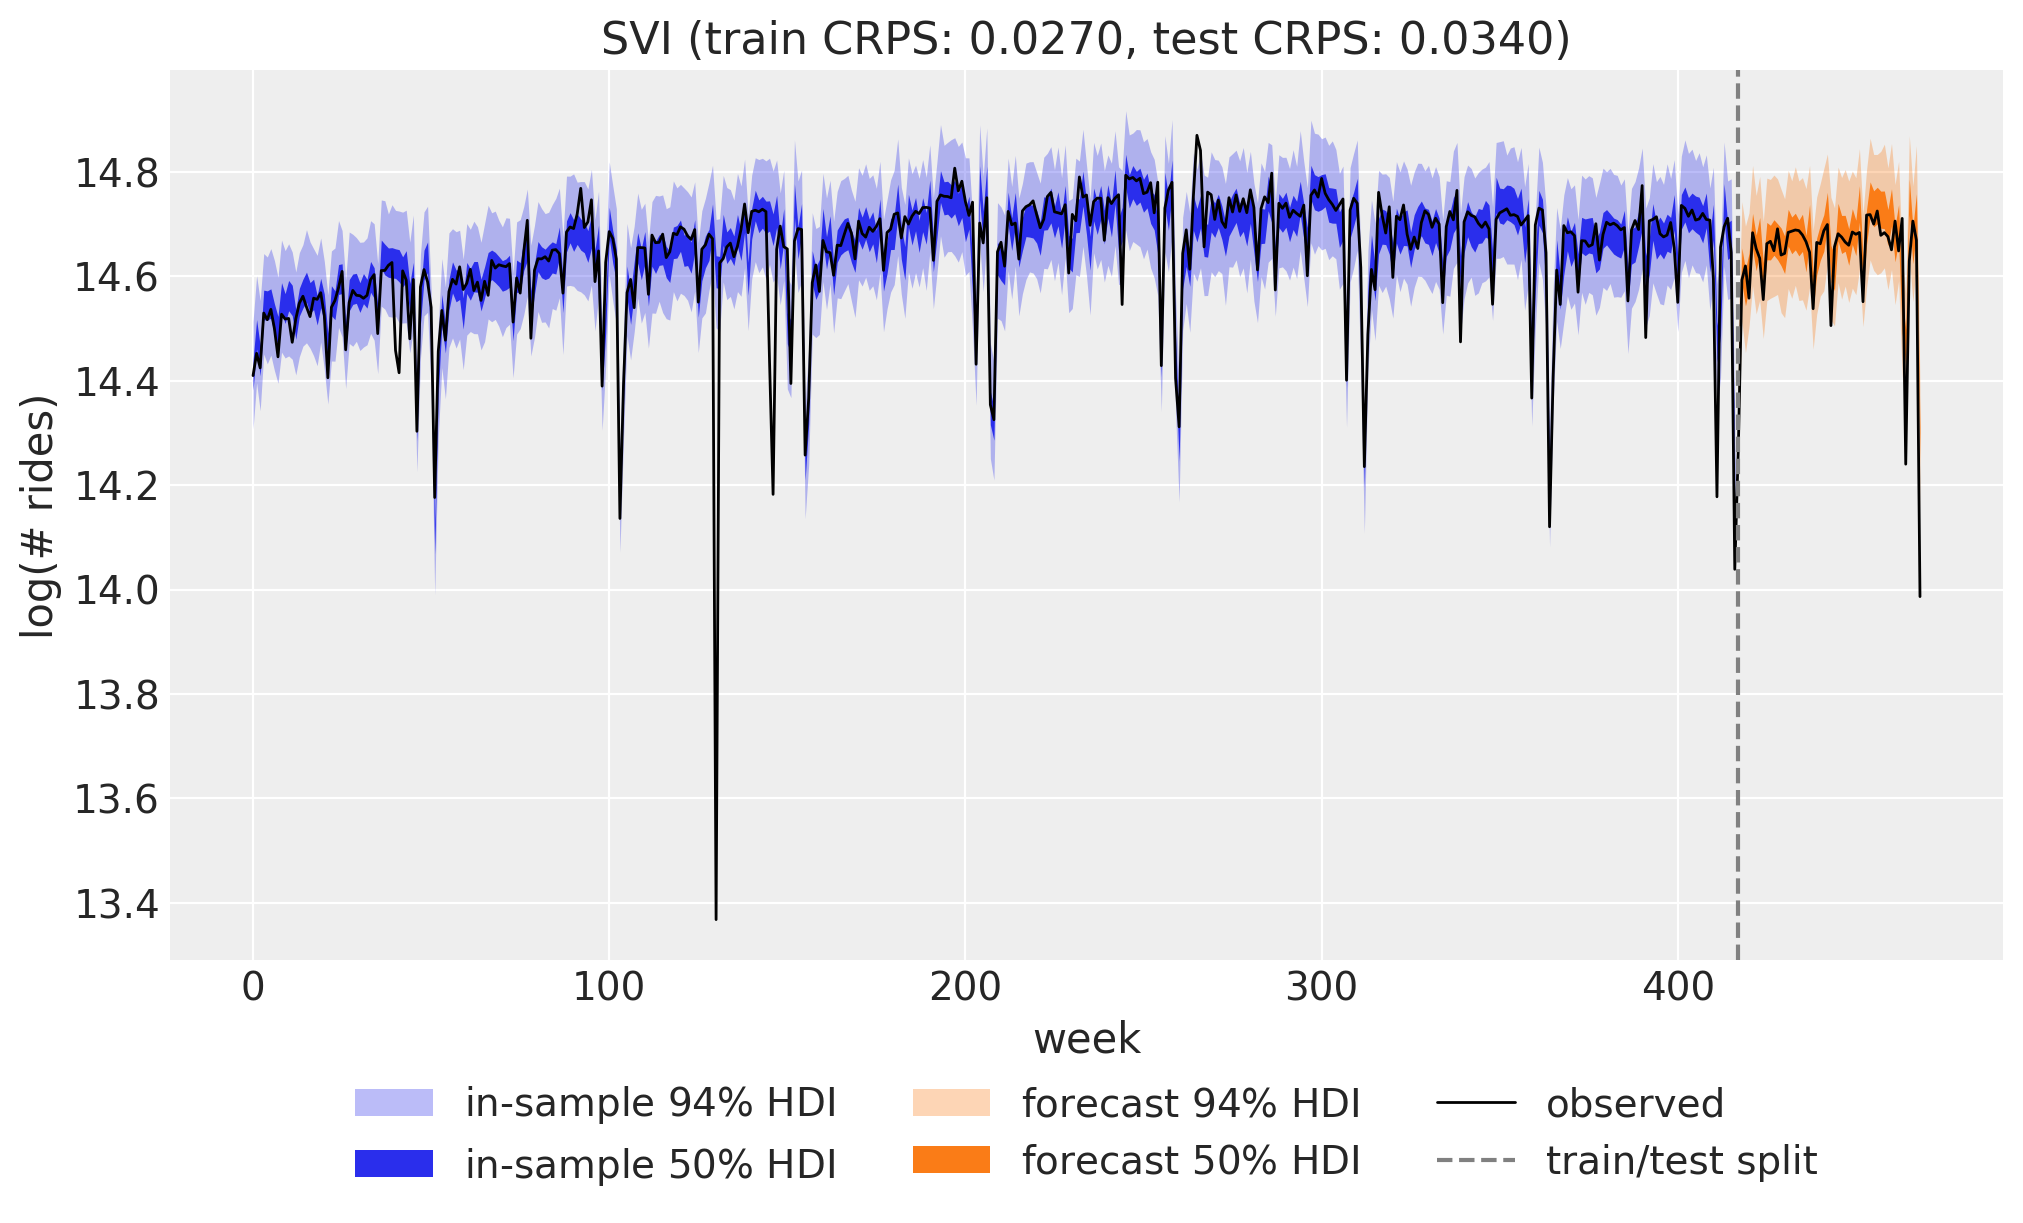

In [15]:
plot_forecast(svi_tree, title=crps_title("SVI"))

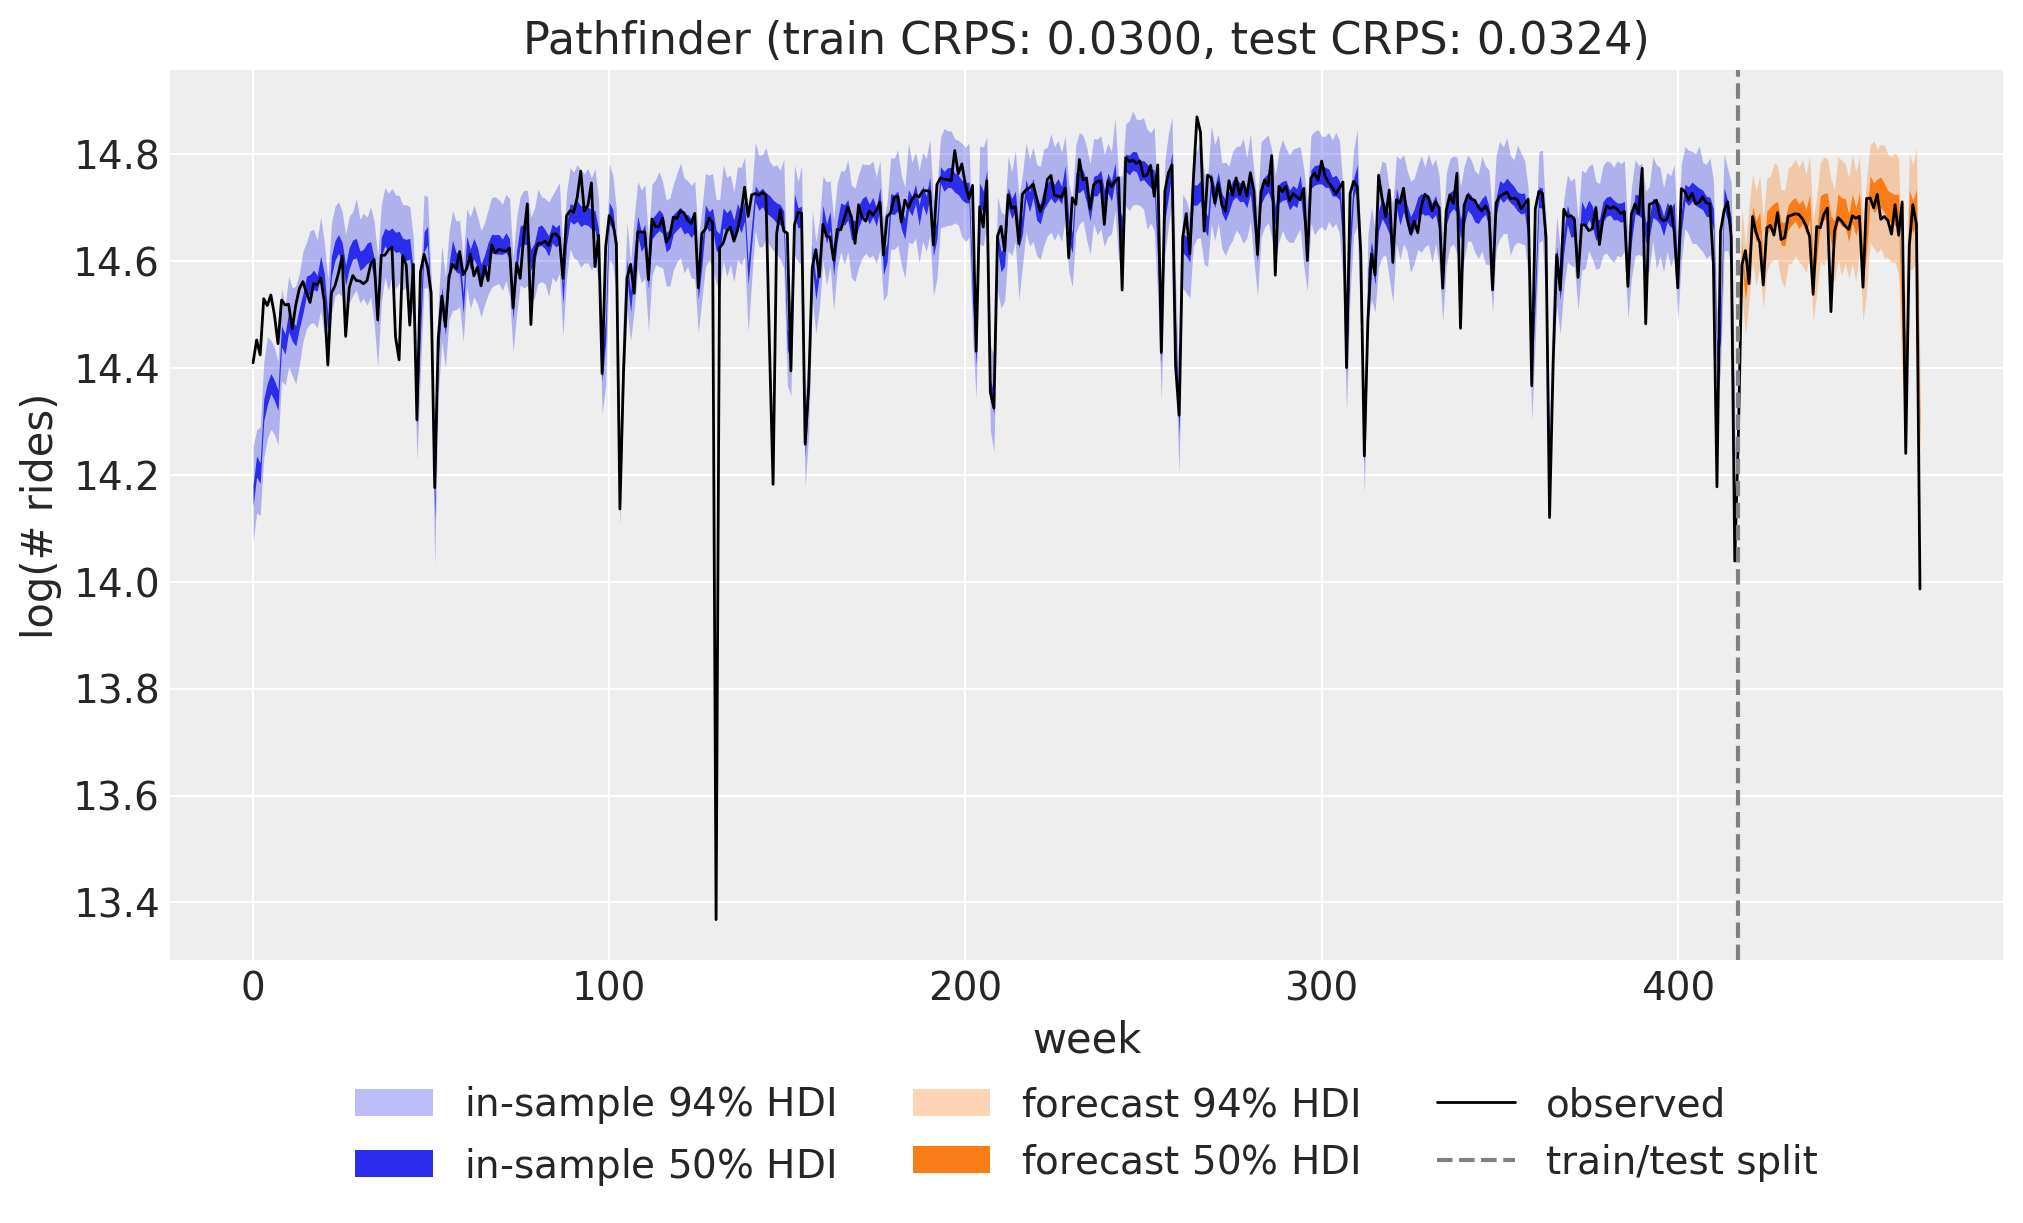

In [16]:
plot_forecast(pathfinder_tree, title=crps_title("Pathfinder"))

## Trade-offs

The summary plot puts the three engines side by side.

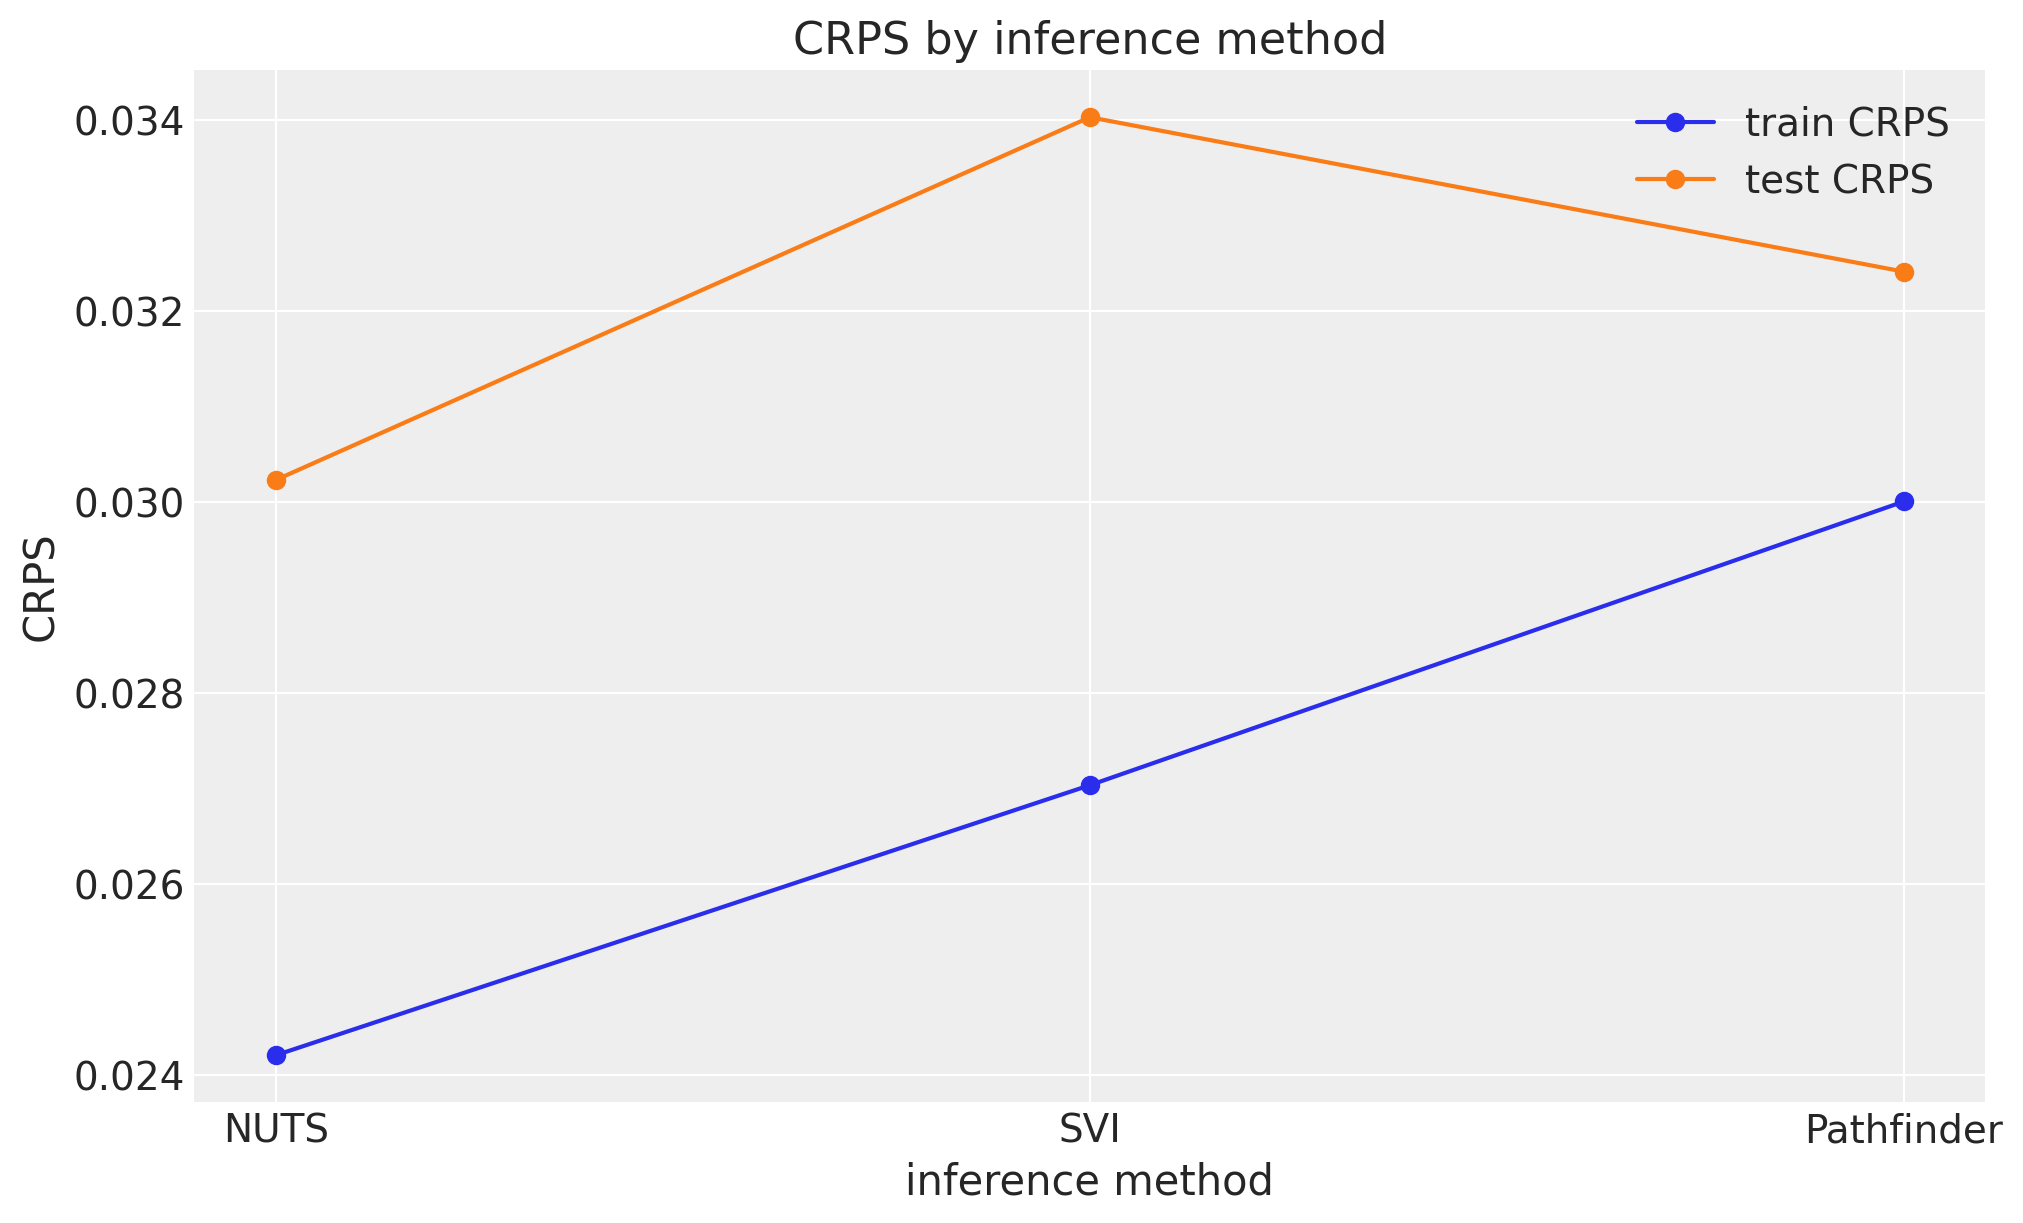

In [17]:
methods = list(crps_results)
train_scores = [crps_results[m]["train"] for m in methods]
test_scores = [crps_results[m]["test"] for m in methods]

fig, ax = plt.subplots()
ax.plot(methods, train_scores, "o-", color="C0", label="train CRPS")
ax.plot(methods, test_scores, "o-", color="C1", label="test CRPS")
ax.legend()
ax.set(title="CRPS by inference method", xlabel="inference method", ylabel="CRPS");

All three engines land in the same CRPS range, which is reassuring: the posterior of this model is well behaved enough that normal approximations capture what matters for forecasting. Within that range the ordering follows the usual cost-accuracy ladder. NUTS samples the exact posterior and sets the reference score on both windows, at the highest wall-clock cost. SVI gets close to the reference in a few seconds, with the one-cycle schedule doing the heavy lifting; it is the cheapest option here, but it earns that speed through optimizer tuning. Pathfinder needs no tuning beyond its iteration budget and path count, lands between the two, and its paths parallelize trivially, which makes it a great first pass or an initializer before committing to a longer fit. On a model this small the absolute time differences are modest; they grow quickly with model size, and that is when the cheap engines pay off.

## Next steps

A single train/test split is only one view of forecasting skill; the [univariate example](forecasting_univariate.html) shows how to score these same models with rolling-origin backtesting, including a fully vectorized variant. From here you can also swap guides (`guide=AutoMultivariateNormal` captures posterior correlations that `AutoNormal` ignores), swap kernels (the `numpyro_forecast.contrib.blackjax` module provides BlackJAX NUTS and MCLMC kernels that plug into `fit_mcmc`), or move to the object-oriented wrappers `Forecaster`, `HMCForecaster`, and `PathfinderForecaster` when you do not need the fit objects themselves.

## References

- Orduz, J. [*Univariate time series forecasting with NumPyro*](https://juanitorduz.github.io/numpyro_forecasting-univariate/).
- Pyro. [*Forecasting I: Univariate, Heavy Tailed*](https://pyro.ai/examples/forecasting_i.html).
- Hoffman, M. D., & Gelman, A. (2014). [*The No-U-Turn Sampler: Adaptively setting path lengths in Hamiltonian Monte Carlo*](https://jmlr.org/papers/v15/hoffman14a.html). JMLR.
- Hoffman, M. D., Blei, D. M., Wang, C., & Paisley, J. (2013). [*Stochastic variational inference*](https://jmlr.org/papers/v14/hoffman13a.html). JMLR.
- Zhang, L., Carpenter, B., Gelman, A., & Vehtari, A. (2022). [*Pathfinder: Parallel quasi-Newton variational inference*](https://jmlr.org/papers/v23/21-0889.html). JMLR.
- Smith, L. N., & Topin, N. (2019). [*Super-convergence: Very fast training of neural networks using large learning rates*](https://arxiv.org/abs/1708.07120).